IA & Data science (LU3IN0226) -- 2024-2025
--------
*&copy; Equipe pédagogique: Christophe Marsala, Olivier Schwander, Jean-Noël Vittaut.*


# Mini-projet final

<font size="+1" color="RED">**[Q]**</font> **Indiquer dans la boîte ci-dessous vos noms et prénoms :**

*Double-cliquer ici et insérer les noms et prénoms de votre binôme*

Ce projet peut être fait en binôme (et c'est fortement conseillé) ou tout seul.

Le nom de chaque membre du binôme doit être indiqué, et <u>**un seul rendu sur un des deux comptes Moodle doit être fait**</u>.

Les groupes de plus de 2 personnes ne sont pas autorisés.

**La dernière séance de TD-TME11 de votre groupe sera réservée pour travailler sur ce mini-projet.**

<font color="RED" size="+1"><b>[Q]</b></font> **Renommer ce fichier ipython**

**Nom à donner au fichier à poster** : *projet-Nom1_Nom2.ipynb* 
- *Nom1* et *Nom2* : noms des membres du binôme
- ne pas compresser ou faire une archive: il faut rendre le fichier ipython tel quel, éventuellement, si vous avez d'autres fichiers vous les rendez séparément.

**Le compte-rendu est soumis sur la page Moodle.**

# Projet 2 - avril-mai 2025


<font size="+1" color="RED"><b>Date de rendu : au plus tard le lundi 19 mai 2025, avant 11h</b></font>
    
<b>Attention! le site Moodle ferme à 11h pile !</b> prévoyez de vous y connecter au moins 15mn avant la fermeture...
<b>Il n'y aura pas de prolongation possible.</b>

Vous devez compléter ce notebook en rajoutant vos expérimentations avec vos algorithmes d'apprentissage sur les données fournies dans le répertoire `data`.



## Travail à faire

Appliquer les algorithmes d'apprentissage vus en cours sur les données comme décrit ci-dessous afin de mettre en évidence des résultats intéressants.


## Compte-rendu demandé
Ce qui doit être remis avant la date limite : un fichier archive (`.tar`, `.tgz`, ou `.zip` uniquement) contenant:
- ce **notebook** complété. Il doit pouvoir être exécuté sans autre apport (pensez à vous en assurer avant de le rendre). 
- votre **librairie iads** sous la forme d'une archive avec votre répertoire `iads/` contenant tous les fichiers nécessaires 
- un **poster** sous la forme d'un fichier PDF dont le nom est de la forme: *tme11-Nom1_Nom2.pdf* qui correspond à un poster décrivant l'ensemble des expérimentations menées et les résultats obtenus.


<b>IMPORTANT</b>: 
- Les <u>fichiers de données ne doivent pas être inclus dans votre archive</u> ! 
- Pensez à vérifier que votre archive contient bien tous les fichiers demandés et **seulement** les fichiers demandés.
- **Tous les fichiers demandés doivent être soumis avant la date limite*, le jour de la soutenance, vous pourrez fournir des versions (légèrement) modifiées.

## Soutenance des projets
La soutenance aura lieu le <font size="+1" color="RED">**mardi 20 mai 2025**</font>, à partir de 9h. Un ordre de passage ainsi que la salle de TME où aura lieu les soutenances seront affichées sur le Moodle la veille (la remise d'un compte-rendu avant lundi 19 mai 11h est obligatoire pour être autorisé à passer une soutenance).

La <b>soutenance est obligatoire</b> : tout projet pour lequel une soutenance n'a pas eu lieu sera noté $0$.

Modalités de la soutenance:
- durée de la soutenance : 10 mn pour un binôme, 7 mn pour un monôme ;
- elle a lieu devant un ordinateur avec le notebook et le poster comme support ;
    - elle commence par une rapide présentation des expérimentations réalisées et résultats obtenus (max. 4 à 5mns)
    - puis elle se poursuit par des questions posées individuellement aux membres du binômes sur les expériences ou le code python réalisé.
- la note de soutenance est individuelle pour chaque membre d'un binôme.


**Très important** : les fichiers de données doivent être placés de façon à respecter la structure de fichiers suivante :

          --iads/
              -- Classifiers.py
              -- etc.
          -- MiniProjet/
              -- ce_notebook.ipynb

Les données seront chargées par les commandes de chargement des données fournies dans ce notebook (ci-dessous).

Dans le notebook que vous rendrez, le chargement des fichiers de données doit considérer cette arborescence.



In [38]:
# Importation de librairies standards:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline  

# un nouvel import utile pour la 3D:
from matplotlib import cm

# Les instructions suivantes sont TRES utiles pour recharger automatiquement 
# le code modifié dans les librairies externes
%load_ext autoreload
%autoreload 2

# Pour mesurer le temps
import time

# Importation de votre librairie iads:
# La ligne suivante permet de préciser le chemin d'accès à la librairie iads
import sys
sys.path.append('../')   # iads doit être dans le répertoire père du répertoire courant !

# Importation de la librairie iads
import iads as iads

# importation de Classifiers
from iads import Classifiers as classif

# importation de utils
from iads import utils as ut

# importation de evaluation
from iads import evaluation as ev

# importation de Clustering
from iads import Clustering as clust

# commande TRES utile pour recharger automatiquement le code que vous modifiez dans les modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Données pour le projet : 20newsgroups

Les données sont fournies dans le fichier CSV `20newsgroups.csv` contenu dans l'archive. Une documentation sur ces données peut être consultée sur la <a href="http://qwone.com/~jason/20Newsgroups/" target="NEW">page ScikitLearn</a>.
Ces données sont des dépêches issues de 20 groupes de discussions.


### Chargement des données

### Prétraitement

Dans un premier temps, vous devez appliquer les étapes de prétraitements vues dans le TME 6. Pour le nettoyage, la liste des mots inutiles (stopwords) est fournie dans le fichier `stopwords.csv` de l'archive

In [39]:
import string 
def filtre(df, stop_words):
    """ 
    Nettoie chaque ligne textuelle d'un DataFrame et ajoute une nouvelle colonne 'mots_filtre' 
    contenant la liste des mots filtrés

    Paramètre :
    -----------
    df : pandas.DataFrame
        un DataFrame dont la première colonne contient des chaînes de caractères (textes à nettoyer)
    stop_words : pandas.DataFrame
        un DataFrame contenant la liste de mots vides stockée dans une seule colonne

    Retour : 
    --------
    pandas.DataFrame 
        Le DataFrame d'origine, avec une colonne supplémentaire "mots_filtre"
    
    """
    stop_words = set(stop_words.iloc[:,0])
    
    def nettoyer_ligne(ligne):
        if pd.isna(ligne):
            return []  # Ligne vide → on retourne une liste vide
        
        ligne = ligne.replace("'", " ")
        ligne = ligne.translate(str.maketrans('', '', string.punctuation))
        ligne = ligne.lower()
        mots = ligne.split()
        mots_filtres = []
        for mot in mots:
            if mot in stop_words:
                continue 
            mots_filtres.append(mot)
        return mots_filtres

    # On applique la fonction à chaque ligne et on stocke le résultat dan s une nouvelle colonne
    df['mots_filtre'] = df.iloc[:, 0].apply(nettoyer_ligne)
    
    return df

def organiser(df):  
    """
    Organise les documents textuels par groupe (ou catégorie) en fonction de leurs labels (targets)

    Paramètres: 
    df : pandas.DataFrame 
        DataFrame contenant les colonnes "target" (entier de 0 à 19)
        et "mots_filtre" (liste de mots nettoyés pour chaque document)
    Retour : 
        La fonction retourne 'groupes' = dictionnaire de texte = dict * vect[mot]
        groupes : dict[int, list[list[str]])
    """
    groupes = {i: [] for i in range(20)}  # initialise les 20 groupes
    
    for _, row in newsgroups_df.iterrows():
        groupe = row['target']
        message = pd.Series(row['mots_filtre'])   
        groupes[groupe].append(message)
        
    return groupes 
# Maintenant 'groupes' contient : pour chaque numéro, la liste des messages


In [40]:
import math
def tf_idf(desc, voc):
    """
    Calcule la représentation vectorielle TF-IDF (Term Frequency - Inverse Document Frequency)
    pour un ensemble de documents

    Paramètres: 
        desc : pd.Series
            Une série de documents, où chaque élément est une liste de mots prétraités
        voc : dict
            Un dictionnaire associant chaque mot du vocabulaire à un index (mot -> index)

    Retour : 
        tdidf : dict
            Un dictionnaire tel que tfidf[i][j] donne le score TF-IDF du mot d'index j dans le document i

    Description de l'algorithme :
    -----------------------------

    On note : 
    - N : nombre total de documents
    - tf_{i,j} : fréquence du mot j dans le document i
    - df_j : nombre de documents contenant le mot j
    - idf_j = log(N / (1 + df_j)): inverse document frequency 
    - tfidf_{i,j} = tf_{i,j} * idf_j
    """
    nb_doc = len(desc)
    tf = {}
    nb_fois_motdanstext = {}

    # TF
    for i in range(nb_doc): # parcours des textes
        dict_temp = {}
        dict_si_mot_apparait = set()
        somme = 0
        for mot in desc[i]:
            if mot in voc : 
                j = voc[mot]
                dict_temp[j] = dict_temp.get((j),0) + 1
                dict_si_mot_apparait.add(mot)
                somme += 1

        for mot in dict_si_mot_apparait:
            nb_fois_motdanstext[mot] = nb_fois_motdanstext.get((mot),0) + 1 
        tf[i] = dict_temp

    # IDF 
    idf = {}
    for mot in nb_fois_motdanstext.keys():
        idf[mot] = math.log(nb_doc / (1 + nb_fois_motdanstext[mot]))

    # TF-IDF
    inv_voc = {index: mot for mot,index in voc.items()}
    for i in range(nb_doc):
        for j in tf[i].keys():     
            mot = inv_voc[j]
            tf[i][j] = tf[i][j] * idf[mot]
    
    # si je veux normalisé dict_temp[j] /= somme
    
    return tf

def arrondir_tfidf(tfidf_dict, precision = 4): 
    tfidf_arrondi = {}
    for doc_id, dico in tfidf_dict.items():
        tfidf_arrondi[doc_id] = {str(k): round(v,precision) for k, v in dico.items()}
    return tfidf_arrondi

## Tâches à réaliser

In [41]:
#Objectif 1 : classifier/ catégoriser les 10 mots les plus utilisés dans chaque groupe
# - regrouper les messages par groupe 

"""
Peut on regrouper automatiquement des documents selon leur contenu et identifier à quel point ces groupes 
reflètent les vraies catégories ? 

--> Apprentissage non supervisé :
Clustering (k-means, hiérarchique) sur les documents pour détecter les groupes natuellement présents

--> Apprentissage supervisé : 
Classifieurs (KNN, perceptron, Arbre de décision) pour prédire la catégorie (étiquettes connues)

--> Objectifs:
-Comparer la structure trouvée automatiquement à la structure imposée

donc ca essaie de savoir si chaque groupe est assez unique pour qu'il soit differencier
"""

"\nPeut on regrouper automatiquement des documents selon leur contenu et identifier à quel point ces groupes \nreflètent les vraies catégories ? \n\n--> Apprentissage non supervisé :\nClustering (k-means, hiérarchique) sur les documents pour détecter les groupes natuellement présents\n\n--> Apprentissage supervisé : \nClassifieurs (KNN, perceptron, Arbre de décision) pour prédire la catégorie (étiquettes connues)\n\n--> Objectifs:\n-Comparer la structure trouvée automatiquement à la structure imposée\n\ndonc ca essaie de savoir si chaque groupe est assez unique pour qu'il soit differencier\n"

In [5]:
"""
Etape 1 : Visualisation des jeux de données :

--> Mesurons quels sont les mots les plus utilisés pour chaque groupe
"""

'\nEtape 1 : Visualisation des jeux de données :\n\n--> Mesurons quels sont les mots les plus utilisés pour chaque groupe\n'

In [6]:
import pandas as pd
import json 

newsgroups_df = pd.read_csv("data/20newsgroups.csv")
stop_words_df = pd.read_csv("data/stopwords.csv")

# import dictionnaire_global 
with open("./data/dictionnaire_global.json", "r", encoding="utf-8") as f:
    dictionnaire_global = json.load(f)

# dictionnaire : mot -> index

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [7]:
type(stop_words_df)

pandas.core.frame.DataFrame

In [42]:
import transformation as tr
import fonction as f

temp = f.filtre(newsgroups_df, stop_words_df)
groupes = f.organiser(temp) 

In [43]:
from collections import Counter

# Calcul des mots les plus importantes (somme TF-IDF) pour chaque groupe 
inv_vocab = {index: mot for mot, index in dictionnaire_global.items()}
groupes_tfidf = {} 
mots_categoriel = {}
for g in range(20):
    desc = groupes[g] 
    groupes_tfidf = tf_idf(desc, dictionnaire_global)

    compteur = Counter()
    for doc in groupes_tfidf.values():
         for mot_index, score in doc.items():
             compteur[mot_index] += score
             
    # Top N mots les plus importants dans ce groupe   
    top = [(inv_vocab[i], round(score, 3)) for i, score in compteur.most_common(10)]
    mots_categoriel[g] = top 


NameError: name 'dictionnaire_global' is not defined

In [ ]:
all_rows = [] 
for groupe, contenu in mots_categoriel.items():
    for (mot, poids) in contenu:
        all_rows.append({"groupe_id": groupe, "mot ": mot, "poids ": poids})

mots_categoriel = pd.Series(mots_categoriel)
mots_categoriel.to_csv("mots_categoriel.csv", index=False)
df_mots_categoriel = pd.DataFrame(all_rows)
df_mots_categoriel.to_csv("mots_categoriel_classe.csv", index = False)

In [ ]:
df_lon

In [ ]:
import matplotlib.pyplot as plt

for groupe_id, mot, poids in df_mots_categoriel.items():
    mots_weights[mot] = mots


plt.title("Top 10 mots pour chaque groupe")
plt.tight_layout()
plt.show()

In [ ]:
""" Tache : apprentissage supervisé : perceptron """

In [66]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_reduced)

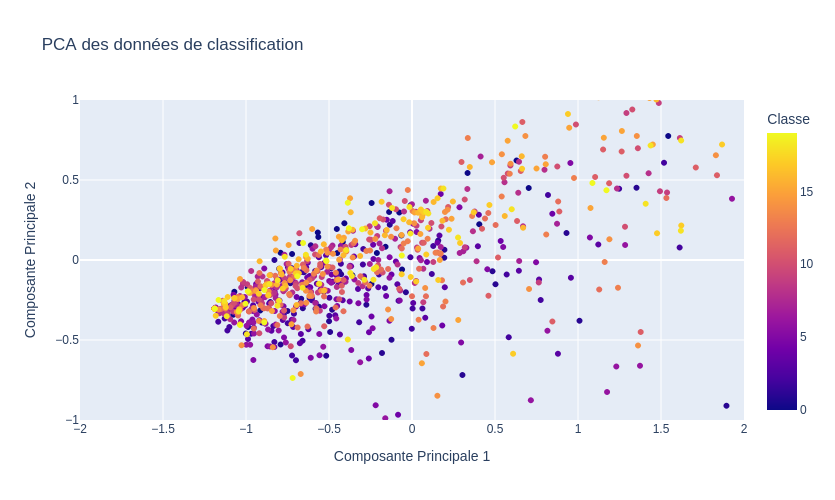

In [85]:
import plotly.express as px
import pandas as pd

# Créer un DataFrame pour faciliter la visualisation
df_pca = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Classe": Y  # On peut aussi faire Y.astype(str) pour forcer un affichage catégoriel
})

# Visualisation interactive
fig = px.scatter(df_pca, x="PC1", y="PC2", color="Classe",
                 title="PCA des données de classification",
                 labels={"PC1": "Composante Principale 1", "PC2": "Composante Principale 2"})

#fig.update_layout(xaxis=dict(zeroline=True), yaxis=dict(zeroline=True))
fig.update_layout(
    xaxis_range=[-2, 2],
    yaxis_range=[-1, 1]
)
fig.update_layout(
    width=800,
    height=500
)
fig.show()


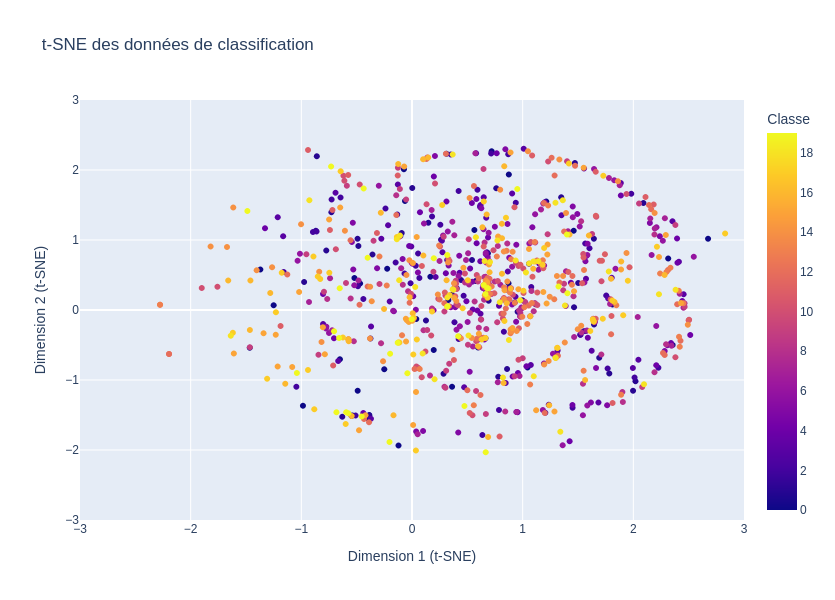

In [80]:
from sklearn.manifold import TSNE
import pandas as pd
import plotly.express as px

# Appliquer t-SNE pour réduire à 2 dimensions
tsne = TSNE(n_components=2, learning_rate='auto', init='pca', perplexity=30, random_state=0)
X_tsne = tsne.fit_transform(X)

#X_tsne_centered = X_tsne - np.mean(X_tsne, axis=0)

# Créer un DataFrame pour la visualisation
df_tsne = pd.DataFrame({
    "Dim1": X_tsne[:, 0],
    "Dim2": X_tsne[:, 1],
    "Classe": Y
})

# Affichage avec Plotly
fig = px.scatter(df_tsne, x="Dim1", y="Dim2", color="Classe",
                 title="t-SNE des données de classification",
                 labels={"Dim1": "Dimension 1 (t-SNE)", "Dim2": "Dimension 2 (t-SNE)"})
#fig.update_layout(xaxis=dict(zeroline=True), yaxis=dict(zeroline=True))
fig.update_layout(
    xaxis_range=[-3, 3],
    yaxis_range=[-3, 3]
)
fig.update_layout(
    width=600,
    height=600
)

fig.show()


In [ ]:
fig = px.scatter(x=X_pca[:, 0], y=X_pca[:, 1], color=y)
fig.update_layout(
    title="PCA visualization of Custom Classification dataset",
    xaxis_title="First Principal Component",
    yaxis_title="Second Principal Component",
)
fig.show()

In [ ]:
import plotly.express as px
from sklearn.datasets import make_classification

X, y = make_classification(
    n_features=6,
    n_classes=3,
    n_samples=1500,
    n_informative=2,
    random_state=5,
    n_clusters_per_class=1,
)


fig = px.scatter_3d(x=X[:, 0], y=X[:, 1], z=X[:, 2], color=y, opacity=0.8)
fig.show()

In [46]:
# apprentissage supervisé
# knn a 5% de la base de donnée
import random 
groupes_05 = {}
dictionnaire_05 = set()

for g, docs in groupes.items():
    n = max(1, int(len(docs) * 0.05))
    groupes_05[g] = random.sample(docs, n)

for docs in groupes_05.values():
    for doc in docs: 
        dictionnaire_05.update(doc)

dictionnaire_05 = {mot: j for j, mot in enumerate(dictionnaire_05)}
"""
groupes_05_10 = {}
for i in range(10):
    groupes_05_10[i] = groupes_05[i]

dictionnaire_05_10 = set()

for docs in groupes_05_10.values():
    for doc in docs: 
        dictionnaire_05_10.update(doc)

dictionnaire_05_10 = {mot: j for j, mot in enumerate(dictionnaire_05_10)}


        
#######################
# prendre 10 groupes parmi 20 car manque de RAM
groupes_20_10 = dict()
for i in range(10):
    groupes_20_10[i] = groupes_20[i]

dictionnaire_20_10 = set()

for docs in groupes_20_10.values():
    for doc in docs:
        dictionnaire_20_10.update(doc) # chaque doc est une liste de mots
        
dictionnaire_20_10 = {mot: j for j, mot in enumerate(dictionnaire_20_10)}
"""

'\ngroupes_05_10 = {}\nfor i in range(10):\n    groupes_05_10[i] = groupes_05[i]\n\ndictionnaire_05_10 = set()\n\nfor docs in groupes_05_10.values():\n    for doc in docs: \n        dictionnaire_05_10.update(doc)\n\ndictionnaire_05_10 = {mot: j for j, mot in enumerate(dictionnaire_05_10)}\n\n\n        \n#######################\n# prendre 10 groupes parmi 20 car manque de RAM\ngroupes_20_10 = dict()\nfor i in range(10):\n    groupes_20_10[i] = groupes_20[i]\n\ndictionnaire_20_10 = set()\n\nfor docs in groupes_20_10.values():\n    for doc in docs:\n        dictionnaire_20_10.update(doc) # chaque doc est une liste de mots\n        \ndictionnaire_20_10 = {mot: j for j, mot in enumerate(dictionnaire_20_10)}\n'

In [47]:
len(dictionnaire_05)

21216

In [49]:
# knn 
# transformé en binary 

vocab_size = len(dictionnaire_05)
docs = []
labels = []

for classe, liste_docs in groupes_05.items():
    for doc in liste_docs:
        docs.append(doc)      # chaque doc = liste de mots
        labels.append(classe) # on garde le label associé

nb_docs = len(docs)
X = np.zeros((nb_docs, vocab_size), dtype=int)

for i, doc in enumerate(docs):
    for mot in set(doc):  # set pour éviter les doublons
        if mot in dictionnaire_05:
            j = dictionnaire_05[mot]
            X[i][j] = 1

Y = np.array(labels)
    

In [50]:
len(Y)

932

In [57]:

# Exemple pour ne garder que les 1000 mots les plus fréquents
from sklearn.feature_selection import SelectKBest, mutual_info_classif

X_filtered = SelectKBest(mutual_info_classif, k=1000).fit_transform(X,Y)


In [58]:
import numpy as np

# Sum des colonnes = nombre d'occurrences globales de chaque mot
word_counts = np.asarray(X.sum(axis=0)).ravel()

# Garde uniquement les mots fréquents : ici au moins dans 3 documents
min_occurrences = 3
selected_indices = np.where(word_counts >= min_occurrences)[0]


In [59]:
selected_indices.shape

(4399,)

In [60]:
X_reduced.shape

(932, 4399)

In [61]:
from scipy.sparse import csr_matrix

X_reduced = X[:, selected_indices]

In [62]:
# index_mots : dict {mot -> index}
# On inverse pour obtenir {index -> mot}
inv_index_mots = {index: mot for mot, index in dictionnaire_05.items()}

# Créer un nouveau vocabulaire réduit
index_mots_reduced = {
    inv_index_mots[index]: mot
    for mot, index in enumerate(selected_indices)
}


In [63]:
len(index_mots_reduced)

4399

In [25]:
    len(X_reduced[0])
# ok, Y meme taille que X_reduced

1916

In [26]:
# Trouver les documents devenus vides
doc_lengths = np.asarray(X_reduced.sum(axis=1)).ravel()
empty_docs = np.where(doc_lengths == 0)[0]
print(f"{len(empty_docs)} documents sont maintenant vides après réduction.")


19 documents sont maintenant vides après réduction.


In [39]:
"""
Essaie de l'évaluation croisée de KNN pour les 20 groupes
résultat : l'éxécution du programme ne se termine jamais
--> donc abandon 
"""

knn = classif.ClassifierKNN(len(dictionnaire_05),5)
cl_multi = classif.ClassifierMultiOAA(knn)
perf_knn = ev.validation_croisee(cl_multi, (X,Y), 10)




start:  0  end :  3
start:  0  end :  4
start:  0  end :  4
start:  0  end :  4
start:  0  end :  4
start:  0  end :  4
start:  0  end :  4
start:  0  end :  4
start:  0  end :  4
start:  0  end :  4
start:  0  end :  4
start:  0  end :  4
start:  0  end :  4
start:  0  end :  4
start:  0  end :  4
start:  0  end :  4
start:  0  end :  4
start:  0  end :  4
start:  0  end :  3
start:  0  end :  3
Fini cross_val
fini deepcopy
RAM utilisée : 36.1%
créer copy
créer copy
créer copy
créer copy
créer copy
créer copy
créer copy
créer copy
créer copy
créer copy
créer copy
créer copy
créer copy
créer copy
créer copy
créer copy
créer copy
créer copy
créer copy
créer copy
fini train
debut accuracy
accuracy
Itération 0: taille base app.=855 taille base test=77 Taux de bonne classif: 0.06493506493506493
start:  3  end :  6
start:  4  end :  8
start:  4  end :  8
start:  4  end :  8
start:  4  end :  8
start:  4  end :  8
start:  4  end :  8
start:  4  end :  8
start:  4  end :  8
start:  4  end :  

([np.float64(0.06493506493506493),
  np.float64(0.05194805194805195),
  np.float64(0.03896103896103896),
  np.float64(0.05194805194805195),
  np.float64(0.07792207792207792),
  np.float64(0.025974025974025976),
  np.float64(0.05194805194805195),
  np.float64(0.06493506493506493),
  np.float64(0.07792207792207792),
  np.float64(0.058577405857740586)],
 np.float64(0.05650709123512472),
 np.float64(0.015381929449590628))

In [48]:
perf_knn = (
    [round(x, 3) for x in [
        0.06493506493506493,
        0.0519480519480519,
        0.03896103896103896,
        0.05194805194805195,
        0.07792207792207792,
        0.02597402597402597,
        0.05194805194805195,
        0.06493506493506493,
        0.07792207792207792,
        0.058577405857740586
    ]]
)


10


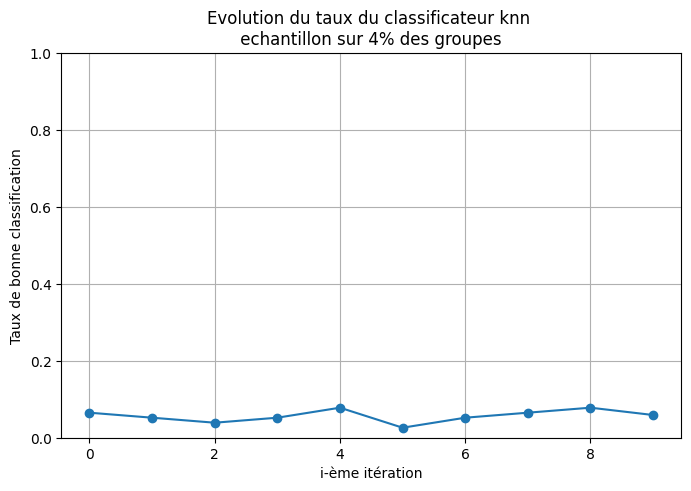

In [49]:
print(len(perf_knn))
plt.figure(figsize=(8,5))
plt.plot(list(range(10)), perf_knn, marker='o')
plt.xlabel("i-ème itération")
plt.ylabel("Taux de bonne classification")
plt.title("Evolution du taux du classificateur knn \n echantillon sur 4% des groupes ")
plt.grid(True)
plt.ylim(0,1)
plt.show()

In [13]:
# sous partie 2 : perceptron :

In [27]:
perceptronbiais = classif.ClassifierPerceptronBiais(len(index_mots_reduced))
cl_p_multi = classif.ClassifierMultiOAA(perceptronbiais)
print("commencé")
perf, taux_moyen, taux_ecart = ev.validation_croisee(cl_p_multi, (X_reduced,Y), 10)


commencé
start:  0  end :  3
start:  0  end :  4
start:  0  end :  4
start:  0  end :  4
start:  0  end :  4
start:  0  end :  4
start:  0  end :  4
start:  0  end :  4
start:  0  end :  4
start:  0  end :  4
Fini cross_val
fini deepcopy
RAM utilisée : 19.2%
créer copy
créer copy
créer copy
créer copy
créer copy
créer copy
créer copy
créer copy
créer copy
créer copy
fini train
debut accuracy
accuracy
Itération 0: taille base app.=438 taille base test=39 Taux de bonne classif: 0.358974358974359
start:  3  end :  6
start:  4  end :  8
start:  4  end :  8
start:  4  end :  8
start:  4  end :  8
start:  4  end :  8
start:  4  end :  8
start:  4  end :  8
start:  4  end :  8
start:  4  end :  8
Fini cross_val
fini deepcopy
RAM utilisée : 19.4%
créer copy
créer copy
créer copy
créer copy
créer copy
créer copy
créer copy
créer copy
créer copy
créer copy
fini train
debut accuracy
accuracy
Itération 1: taille base app.=438 taille base test=39 Taux de bonne classif: 0.46153846153846156
start:  6

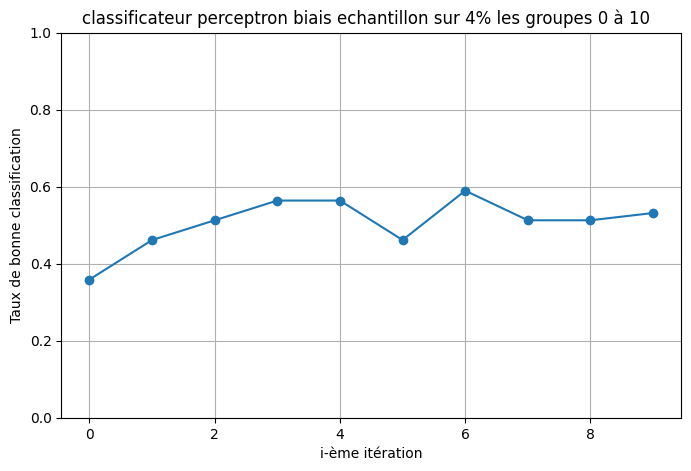

In [28]:
plt.figure(figsize=(8,5))
plt.plot(list(range(10)), perf, marker='o')
plt.xlabel("i-ème itération")
plt.ylabel("Taux de bonne classification")
plt.title("classificateur perceptron biais echantillon sur 4% les groupes 0 à 10  ")
plt.grid(True)
plt.ylim(0,1)
plt.show()

In [37]:
print(perf)
print(taux_ecart)
print(taux_moyen)

[np.float64(0.4025974025974026), np.float64(0.4155844155844156), np.float64(0.44155844155844154), np.float64(0.45454545454545453), np.float64(0.42857142857142855), np.float64(0.4025974025974026), np.float64(0.4805194805194805), np.float64(0.4025974025974026), np.float64(0.4935064935064935), np.float64(0.38493723849372385)]
0.03436518251069556
0.43070151605716467


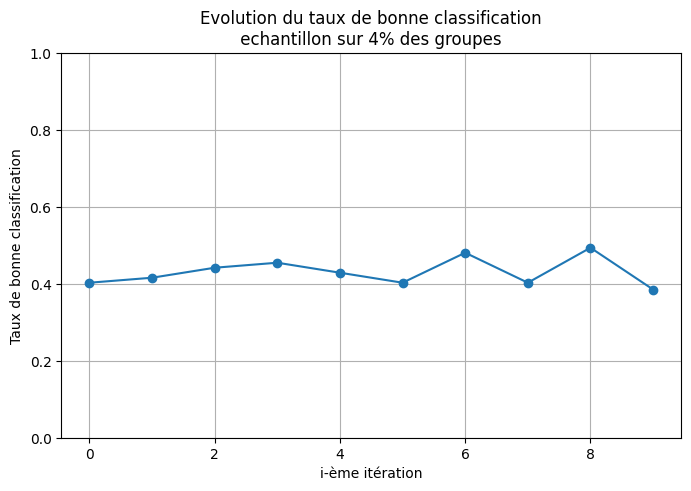

In [38]:
plt.figure(figsize=(8,5))
plt.plot(list(range(10)), perf, marker='o')
plt.xlabel("i-ème itération")
plt.ylabel("Taux de bonne classification")
plt.title("Evolution du taux de bonne classification\n echantillon sur 4% des groupes ")
plt.grid(True)
plt.ylim(0,1)
plt.show()

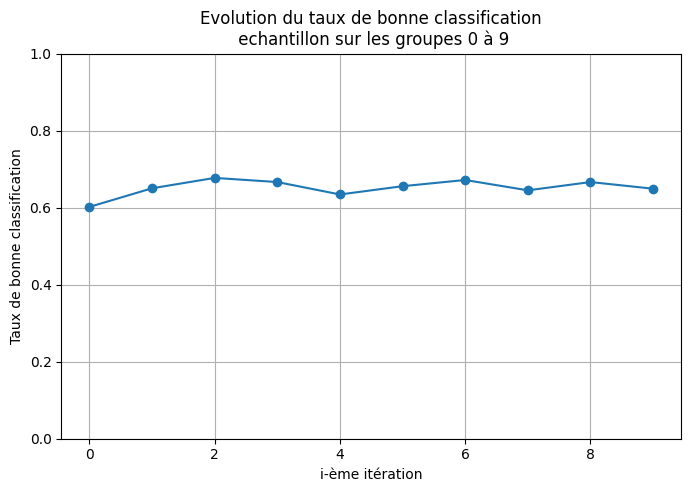

In [23]:
plt.figure(figsize=(8,5))
plt.plot(list(range(10)), perf, marker='o')
plt.xlabel("i-ème itération")
plt.ylabel("Taux de bonne classification")
plt.title("Evolution du taux de bonne classification\n echantillon sur les groupes 0 à 9")
plt.grid(True)
plt.ylim(0,1)
plt.show()

In [ ]:
# Premice visualisation des mots qui permet de classer leur groupes 
# ils doivent etre frequent dans le groupe mais distinct 
import json 

with open("./data/groupes_organiser.json", "r", encoding="utf-8") as f:
    groupes_organiser = 

In [ ]:
#Arbre de décision 

In [50]:
liste_NOM = list()
for mot in index_mots_reduced.keys():
    liste_NOM.append(mot)

In [51]:
liste_NOM[0]

'posted'

In [16]:
# Exemple pour ne garder que les 1000 mots les plus fréquents
from sklearn.feature_selection import SelectKBest, mutual_info_classif

X_filtered = SelectKBest(mutual_info_classif, k=1000).fit_transform(X, Y)


In [17]:
X_filtered.shape

(1925, 1000)

In [18]:
X.shape

(1925, 29650)

In [54]:
arbre_decision = classif.ClassifierArbreDecision(len(index_mots_reduced),0.01,liste_NOM)
perf_AD, taux_moyen_AD, taux_ecart_AD = ev.validation_croisee(cl_p_multi, (X_reduced,Y), 10)

start:  0  end :  3
start:  0  end :  4
start:  0  end :  4
start:  0  end :  4
start:  0  end :  4
start:  0  end :  4
start:  0  end :  4
start:  0  end :  4
start:  0  end :  4
start:  0  end :  4
start:  0  end :  4
start:  0  end :  4
start:  0  end :  4
start:  0  end :  4
start:  0  end :  4
start:  0  end :  4
start:  0  end :  4
start:  0  end :  4
start:  0  end :  3
start:  0  end :  3
Fini cross_val
fini deepcopy
RAM utilisée : 42.9%
créer copy
créer copy
créer copy
créer copy
créer copy
créer copy
créer copy
créer copy
créer copy
créer copy
créer copy
créer copy
créer copy
créer copy
créer copy
créer copy
créer copy
créer copy
créer copy
créer copy
fini train
debut accuracy
accuracy
Itération 0: taille base app.=855 taille base test=77 Taux de bonne classif: 0.44155844155844154
start:  3  end :  6
start:  4  end :  8
start:  4  end :  8
start:  4  end :  8
start:  4  end :  8
start:  4  end :  8
start:  4  end :  8
start:  4  end :  8
start:  4  end :  8
start:  4  end :  

In [ ]:
X_train, Y_train, X_test, Y_test = ev.crossval_strat(X_reduced,Y,10,1)
arbre_decision.train(X_train,Y_train)

start:  3  end :  6
start:  4  end :  8
start:  4  end :  8
start:  4  end :  8
start:  4  end :  8
start:  4  end :  8
start:  4  end :  8
start:  4  end :  8
start:  4  end :  8
start:  4  end :  8
start:  4  end :  8
start:  4  end :  8
start:  4  end :  8
start:  4  end :  8
start:  4  end :  8
start:  4  end :  8
start:  4  end :  8
start:  4  end :  8
start:  3  end :  6
start:  3  end :  6


In [57]:
import networkx as nx
G = nx.DiGraph()
arbre_decision.draw(G)

AttributeError: 'NoneType' object has no attribute 'to_graph'

In [ ]:
arbre_decision.predic

In [3]:
# Partie 1 : non supervisé : 
# 3 méthodes : K-moyennes, K-médoides , clustering hiérarchique 
# première étape : transformer les textes en vecteur numérique

In [6]:
#recuperation des donnes 
import json 

with open("./data/binary_group.json", "r", encoding="utf-8") as f:
    binary_global = json.load(f);
    # binary_group : dict*dict
with open("./data/comptage_global.json", "r", encoding="utf-8") as f:
    comptage_global = json.load(f)

with open("./data/normalized_global.json", "r", encoding="utf-8") as f:
    normalized_global = json.load(f)

with open("./data/tf_idf_global.json", "r", encoding="utf-8") as f:
    tf_idf_global = json.load(f)

In [ ]:
# clustering 
binary_global 
# trouver une equation de distance : euclidienne 

def compute_distance_matrice(dict):
    docs = list(dict.keys())
    distances = {}
    for i in range(len(docs)):
        for j in range(i+1, len(docs)):
            d1, d2 = docs[i], docs[j]
            dist = 
Z = linkage(binary_global, method = 'average', metric='

In [18]:
# Plus utilisé
def organiser(ensemble, dictionnaire):  
    """
    Organise les documents textuels par groupe (ou catégorie) en fonction de leurs labels (targets)

    Paramètres: 
    ensemble : tout type 
        Paramètre non utilisé dans la fonction actuelle (peut être supprimé ou remplacé si besoin).
    dictionnaire : tout type 
        Paramètre non utilisé non plus (peut être retiré si inutile

    Retour : 
        La fonction retourne 'groupes' = dictionnaire de texte = dict * vect[mot]
    """
    groupes = {i: [] for i in range(20)}
    # Remplissage du dictionnaire
    for index, row in newsgroups_df.iterrows():
        groupe = row['target']
        message = row['mots_filtre']
        
        # Ajoute le message dans la bonne liste
        groupes[groupe].append(message)
        
    return groupes 
# Maintenant 'groupes' contient : pour chaque numéro, la liste des messages


In [47]:
print(type(desc))
print(type(desc.iloc[0]))
print(type((desc.iloc[0])[0]))

<class 'pandas.core.series.Series'>
<class 'list'>
<class 'str'>
70


In [29]:
binary_group = binary(desc, dictionnaire_global)
# ok je peut faire dans tout l'ensemble des données 

In [44]:
#vérification des données
valeurs_i0 = [(i, j) for (i, j) in binary_group if i == 0]
print(valeurs_i0)
sum = 0
for i,j in valeurs_i0:
    sum += binary_group[(i,j)]
print(sum)

[(0, 129825), (0, 29857), (0, 106871), (0, 54325), (0, 110537), (0, 40238), (0, 74411), (0, 73066), (0, 109605), (0, 115654), (0, 83897), (0, 46146), (0, 21738), (0, 31519), (0, 112701), (0, 116631), (0, 65070), (0, 60038), (0, 112670), (0, 51346), (0, 100873), (0, 116625), (0, 109946), (0, 83188), (0, 73019), (0, 143958), (0, 132915), (0, 70459), (0, 123734), (0, 95636), (0, 30922), (0, 116362), (0, 121852), (0, 127741), (0, 23662), (0, 77307), (0, 56179), (0, 57773), (0, 141822), (0, 108631), (0, 32744), (0, 75642), (0, 99768), (0, 41714), (0, 58339), (0, 124301), (0, 30222), (0, 112471), (0, 70852), (0, 25140), (0, 46940), (0, 122051), (0, 69833), (0, 77279), (0, 55369), (0, 58318), (0, 119576)]
57


In [32]:
import json 

d_jon = {str(k) : v for k,v in binary_group.items()}

with open("./data/binary_group.json", "w") as f:
    json.dump(d_jon, f, indent=4)

In [35]:
def comptage(desc, voc):
    X = {}
    for i in range(len(desc)): # parcours des textes
        for mot in desc.iloc[i]:
            if mot in voc : 
                j = voc[mot]
                X[(i,j)] = X.get((i, j), 0) + 1 
    return X

In [38]:
comptage_group = comptage(desc, dictionnaire_global)

#vérification des données
valeurs2_i0 = [(i, j) for (i, j) in comptage_group if i == 0]
print(valeurs2_i0)

[(0, 129825), (0, 29857), (0, 106871), (0, 54325), (0, 110537), (0, 40238), (0, 74411), (0, 73066), (0, 109605), (0, 115654), (0, 83897), (0, 46146), (0, 21738), (0, 31519), (0, 112701), (0, 116631), (0, 65070), (0, 60038), (0, 112670), (0, 51346), (0, 100873), (0, 116625), (0, 109946), (0, 83188), (0, 73019), (0, 143958), (0, 132915), (0, 70459), (0, 123734), (0, 95636), (0, 30922), (0, 116362), (0, 121852), (0, 127741), (0, 23662), (0, 77307), (0, 56179), (0, 57773), (0, 141822), (0, 108631), (0, 32744), (0, 75642), (0, 99768), (0, 41714), (0, 58339), (0, 124301), (0, 30222), (0, 112471), (0, 70852), (0, 25140), (0, 46940), (0, 122051), (0, 69833), (0, 77279), (0, 55369), (0, 58318), (0, 119576)]


In [54]:
sum = 0
for i,j in valeurs2_i0:
    sum += comptage_group[(i,j)]
print(sum)

70


In [55]:
def normalized(desc, voc):
    X = {}
    for i in range(len(desc)): # parcours des textes
        nb_mot = len(desc.iloc[i])
        mot_passe = set()
        for mot in desc.iloc[i]:
            if mot in voc : 
                j = voc[mot]
                X[(i,j)] = X.get((i, j), 0) + 1 
                mot_passe.add((i,j))
        for a,b in mot_passe:
            X[(a,b)] = X[(a,b)]/ nb_mot
    return X

In [57]:
# jeu de test 
normalized_group = normalized(desc, dictionnaire_global)

#vérification des données
valeurs3_i0 = [(i, j) for (i, j) in normalized_group if i == 0]
print(valeurs2_i0)

sum = 0
for i,j in valeurs3_i0:
    sum += normalized_group[(i,j)]
print(sum)

[(0, 129825), (0, 29857), (0, 106871), (0, 54325), (0, 110537), (0, 40238), (0, 74411), (0, 73066), (0, 109605), (0, 115654), (0, 83897), (0, 46146), (0, 21738), (0, 31519), (0, 112701), (0, 116631), (0, 65070), (0, 60038), (0, 112670), (0, 51346), (0, 100873), (0, 116625), (0, 109946), (0, 83188), (0, 73019), (0, 143958), (0, 132915), (0, 70459), (0, 123734), (0, 95636), (0, 30922), (0, 116362), (0, 121852), (0, 127741), (0, 23662), (0, 77307), (0, 56179), (0, 57773), (0, 141822), (0, 108631), (0, 32744), (0, 75642), (0, 99768), (0, 41714), (0, 58339), (0, 124301), (0, 30222), (0, 112471), (0, 70852), (0, 25140), (0, 46940), (0, 122051), (0, 69833), (0, 77279), (0, 55369), (0, 58318), (0, 119576)]
0.9999999999999989


In [61]:
import math

def tf_idf(desc, voc):
    X = {}
    doc_count = {}  # pour calculer combien de documents contiennent chaque mot

    # 1. Comptage brut et doc_count
    for i in range(len(desc)):
        mots_vus = set()
        for mot in desc.iloc[i]:
            if mot in voc:
                j = voc[mot]
                X[(i,j)] = X.get((i,j), 0) + 1
                mots_vus.add(j)
        for j in mots_vus:
            doc_count[j] = doc_count.get(j, 0) + 1

    N = len(desc)  # nombre total de documents

    # 2. Calcul final TF-IDF
    for (i,j) in X:
        nb_mots_doc = len(desc.iloc[i])
        tf = X[(i,j)] / nb_mots_doc
        idf = math.log(N / (1 + doc_count[j]))
        X[(i,j)] = tf * idf

    return X


In [62]:
tf_idf_group = tf_idf(desc, dictionnaire_global)

# Afficher le résultat
for (i,j), value in sorted(tf_idf_group.items()):
    print(f"Doc {i}, mot {j} : {value:.4f}")


AttributeError: 'dict' object has no attribute 'sample'

In [64]:

# Créons un plus grand desc
desc = pd.Series([
    ['chat', 'chien', 'chat'],
    ['chien', 'oiseau', 'oiseau'],
    ['chat', 'lion', 'lion', 'lion'],
    ['chien', 'chat', 'oiseau', 'lion'],
    ['oiseau', 'oiseau', 'lion', 'lion'],
    ['chat', 'chat', 'chat', 'chat'],
    ['chien', 'chien', 'chien'],
    ['lion', 'lion', 'lion', 'lion'],
    ['chat', 'oiseau'],
    ['chien', 'lion']
])

# Vocabulaire indexé
vocabulaire = {'chat': 0, 'chien': 1, 'oiseau': 2, 'lion': 3}

# Test de la fonction
X = tf_idf(desc, vocabulaire)

# Afficher le résultat
for (i,j), value in sorted(X.items()):
    print(f"Doc {i}, mot {j} : {value:.4f}")


Doc 0, mot 0 : 0.3406
Doc 0, mot 1 : 0.1703
Doc 1, mot 1 : 0.1703
Doc 1, mot 2 : 0.4621
Doc 2, mot 0 : 0.1277
Doc 2, mot 3 : 0.3831
Doc 3, mot 0 : 0.1277
Doc 3, mot 1 : 0.1277
Doc 3, mot 2 : 0.1733
Doc 3, mot 3 : 0.1277
Doc 4, mot 2 : 0.3466
Doc 4, mot 3 : 0.2554
Doc 5, mot 0 : 0.5108
Doc 6, mot 1 : 0.5108
Doc 7, mot 3 : 0.5108
Doc 8, mot 0 : 0.2554
Doc 8, mot 2 : 0.3466
Doc 9, mot 1 : 0.2554
Doc 9, mot 3 : 0.2554


### Apprentissage supervisé

*Tâches*: évaluation d'algorithmes et de représentations des données.
- classification binaire
- classification multi-classe

*Etudes suggérées*:
- représentations des données
    - avec ou sans suppression des stopwords
    - différentes représentations: bag-of-words binaire, avec comptage, avec fréquences, avec tfidf
- différents classifiers:
    - perceptron,
    - k-plus proches voisins avec distance euclidienne,
    - k-plus proches voisins avec distance cosinus (cf. TD),
    - Naives Bayes,
    - arbres de décision
- analyse des résultats:
    - accuracy, temps d'exécutions
    - score fold par fold
    - matrice de confusion


In [19]:
# Classifier KNN euclidienne pour les 4 données
print(type(binary_groups)) 
print(type(binary_groups[0]))
print(type(binary_groups[0][0]))
print(type(binary_groups[0][0][0]))
print(binary_groups[0][0][1])

<class 'dict'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.int64'>
0


In [ ]:
knn_eucli_binary = classif.ClassifierKNN()
knn_eucli_binary.X_train = []
knn_eucli_binary.Y_train = []
for label in range(len(binary_groups)):
    knn_eucli_binary.X_train.append(binary_groups[label])
    knn_eucli_binary.Y_train.append(label)


### Apprentissage non-supervisé

*Tâche*: vérifier que le découpage a du sens par rapport aux groupes fournis. 

*Etudes suggérées*:
- étudier l'application d'un clustering hiérarchique et son résultat;
- étudier les résultats de l'application de l'algorithme des k-moyennes, pour différentes valeurs de k;
- proposer des évaluations des clusters trouvés afin de mettre en évidence les plus intéressants:
    - en utilisant les indices d'évaluation présentés en cours;
    - en comparant par diverses méthodes les clusters trouvés avec les vrais labels des classes (targets y).
- proposer une visualisation des résultats obtenus


   


## Poster à rendre dans le compte-rendu (format PDF)

Votre poster doit décrire de façon synthétique **l'ensemble des expérimentations** menées sur les données, les résultats obtenus en apprentissage supervisé et en apprentissage non-supervisé ainsi que les conclusions/bilans que vous tirez de ces expérimentations (ie. ce que vous avez appris sur ces données).

*Remarque*: vous devez indiquer vos noms/prénoms et groupe (1, 2, ou 3) sur le poster.
